# NBA Era Analysis - RQ1

This notebook builds the master analytical dataset from three sources:
- `NBA_Player_Stats_and_Salaries_2010-2025.csv` — box-score stats + salaries (Basketball-Reference)
- `all_seasons.csv` — advanced metrics including `net_rating`, `ts_pct`, `ast_pct`, `usg_pct`, `oreb_pct`, `dreb_pct` (NBA.com/stats)
- `NBA_TEAMS.csv` — team metadata

**Valid analysis window:** seasons 2009-10 through 2022-23 (where both sources overlap).  
The 2023-24 and 2024-25 seasons exist in the stats/salary file but have no advanced metrics in `all_seasons.csv`.

**Primary comparison years:** 2013-14 (year=2014) and 2020-21 (year=2021).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ── Salary cap by season end-year (source: Basketball-Reference) ──────────────
# Covers every season where we have data. Used to normalize salary → cap %.
CAP_MAP = {
    2010: 57700000,
    2011: 58044000,
    2012: 58044000,
    2013: 58679000,
    2014: 63065000,
    2015: 70000000,
    2016: 94143000,
    2017: 99093000,
    2018: 101869000,
    2019: 109140000,
    2020: 109140000,
    2021: 112414000,
    2022: 123655000,
    2023: 136021000,
    2024: 140588000,
    2025: 141000000,
}

# Seasons where both sources overlap (advanced metrics available)
VALID_SEASONS = [
    '2009-10', '2010-11', '2011-12', '2012-13', '2013-14',
    '2014-15', '2015-16', '2016-17', '2017-18', '2018-19',
    '2019-20', '2020-21', '2021-22', '2022-23',
]

print('Imports and constants loaded.')

Imports and constants loaded.


## Step 1 — Load raw files

In [2]:
df_main    = pd.read_csv('NBA Player Stats and Salaries_2010-2025.csv')
df_seasons = pd.read_csv('all_seasons.csv')
df_teams   = pd.read_csv('NBA_TEAMS.csv')

print(f'df_main:    {df_main.shape}  | years {df_main["Year"].min()}–{df_main["Year"].max()}')
print(f'df_seasons: {df_seasons.shape}  | seasons {df_seasons["season"].min()}–{df_seasons["season"].max()}')
print(f'df_teams:   {df_teams.shape}')

df_main:    (7298, 31)  | years 2010–2025
df_seasons: (12844, 22)  | seasons 1996-97–2022-23
df_teams:   (30, 7)


## Step 2 — Clean df_main (box-score stats + salary)

In [3]:
#Standardize column names
df_main.columns = (
    df_main.columns
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('%', '_pct', regex=False)
    .str.lower()
)

#Simplify positions to 5 canonical roles
# The raw data uses hyphenated dual-positions (SF-SG, PF-C, etc.).
# We take the PRIMARY (first) position only.
VALID_POS = {'PG', 'SG', 'SF', 'PF', 'C'}

def simplify_pos(p):
    if not isinstance(p, str):
        return 'Unknown'
    primary = p.split('-')[0].strip().upper()
    return primary if primary in VALID_POS else 'Unknown'

df_main['pos_simple'] = df_main['pos'].apply(simplify_pos)

#Season key: map end-year integer → 'YYYY-YY' string
# e.g. Year=2014 → '2013-14', Year=2021 → '2020-21'
df_main['season_key'] = df_main['year'].apply(
    lambda y: f'{y - 1}-{str(y)[2:]}'
)

#Cap percentage (computed ONCE with a complete cap map)
df_main['cap_pct'] = df_main.apply(
    lambda r: r['salary'] / CAP_MAP.get(r['year'], np.nan), axis=1
)

#Per-year high-volume 3PT shooter flag
#Computed for EVERY year individually so the threshold tracks the era's norm.
df_main['is_high_vol_3pt'] = False
for yr, grp in df_main.groupby('year'):
    q75 = grp['3pa'].quantile(0.75)
    mask = (df_main['year'] == yr) & (df_main['3pa'] >= q75)
    df_main.loc[mask, 'is_high_vol_3pt'] = True

print('df_main cleaned.')
print(f'  Rows: {len(df_main)}')
print(f'  Positions: {df_main["pos_simple"].value_counts().to_dict()}')
print(f'  Season keys: {sorted(df_main["season_key"].unique())}')
print(df_main.columns.tolist())
print(df_main.head(5))

df_main cleaned.
  Rows: 7298
  Positions: {'SG': 1664, 'PF': 1471, 'C': 1422, 'PG': 1374, 'SF': 1367}
  Season keys: ['2009-10', '2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
['player', 'salary', 'year', 'pos', 'age', 'team', 'g', 'gs', 'mp', 'fg', 'fga', 'fg_pct', '3p', '3pa', '3p_pct', '2p', '2pa', '2p_pct', 'efg_pct', 'ft', 'fta', 'ft_pct', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'pos_simple', 'season_key', 'cap_pct', 'is_high_vol_3pt']
             player    salary  year pos  age team   g  gs    mp   fg  ...  \
0       Kobe Bryant  23034375  2010  SG   31  LAL  73  73  38.8  9.8  ...   
1   Jermaine O'Neal  23016000  2010   C   31  MIA  70  70  28.4  5.6  ...   
2     Tracy McGrady  22843124  2010  SG   30  NYK  30  24  22.4  3.0  ...   
3        Tim Duncan  22183220  2010   C   33  SAS  78  77  31.3  7.2  ...   
4  Shaquille O'Neal  21000000

## Step 3 — Clean df_seasons (advanced metrics)

1. **Name normalization** — strip punctuation and name suffixes so `CJ Miles` matches `C.J. Miles` and `Robert Williams III` matches `Robert Williams`.
2. **Deduplication** — a handful of players appear twice per season (mid-season trades). We keep the row with the most games played, which represents their full-season aggregate.
3. **Rename `ast`** — `all_seasons` has `ast` (a different calculation than box-score raw assists). Renaming it `ast_adv` before the merge prevents the `ast_x`/`ast_y` collision that plagued the original code.

In [4]:
#Standardize column names
df_seasons.columns = df_seasons.columns.str.strip().str.lower()
df_seasons = df_seasons.drop(columns=['unnamed: 0'], errors='ignore')

#Rename ast to avoid collision with box-score ast after merge
df_seasons = df_seasons.rename(columns={'ast': 'ast_adv'})

#Name normalization
#Removes: periods (C.J. → CJ), apostrophes (O'Neal → ONeal),
#           hyphens (e.g. Wade-Davis → WadeDavis),
#           and name suffixes Jr / Sr / II / III / IV that differ across sources.
def normalize_name(s):
    s = str(s).strip().lower()
    s = s.replace('.', '').replace("'", '').replace('-', ' ')
    # Remove trailing generational suffixes
    for suffix in [' jr', ' sr', ' ii', ' iii', ' iv']:
        if s.endswith(suffix):
            s = s[: -len(suffix)]
    return s.strip()

df_seasons['_key'] = df_seasons['player_name'].apply(normalize_name)

#Deduplicate: keep row with most games when a player appears twice
#This occurs for a small number of mid-season trade players.
before = len(df_seasons)
df_seasons = (
    df_seasons
    .sort_values('gp', ascending=False)
    .drop_duplicates(subset=['_key', 'season'], keep='first')
    .reset_index(drop=True)
)
print(f'Deduplication: {before} → {len(df_seasons)} rows '
      f'({before - len(df_seasons)} duplicates removed)')

#Restrict to valid overlap window
df_seasons = df_seasons[df_seasons['season'].isin(VALID_SEASONS)].copy()
print(f'After restricting to valid seasons: {len(df_seasons)} rows')
print(f'Seasons covered: {sorted(df_seasons["season"].unique())}')
print(df_seasons.columns.tolist())
print(df_seasons.head(5))

Deduplication: 12844 → 12840 rows (4 duplicates removed)
After restricting to valid seasons: 7058 rows
Seasons covered: ['2009-10', '2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
['player_name', 'team_abbreviation', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast_adv', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season', '_key']
          player_name team_abbreviation   age  player_height  player_weight  \
7       Mikal Bridges               BKN  26.0         198.12      94.800728   
11       Jarrett Jack               NOH  27.0         190.50      89.357624   
13     Ramon Sessions               MIL  28.0         190.50      86.182480   
14         Josh Smith               HOU  29.0         205.74     102.058200   
27  Kenyon Martin Jr.               HOU  22.0         200.66      

## Step 4 — Merge and validate

Left-join on `(normalized_player_name, season_key)`. Every row in df_main is preserved; advanced metrics are added where available.

In [5]:
#Apply the same name normalization to df_main
df_main['_key'] = df_main['player'].apply(normalize_name)

#Columns to bring over from df_seasons
ADV_COLS = [
    '_key', 'season',
    'net_rating', 'ts_pct', 'ast_adv', 'ast_pct',
    'usg_pct', 'oreb_pct', 'dreb_pct',
    'gp',           # games played from advanced dataset (cross-check)
    'pts', 'reb',   # per-game pts/reb from NBA.com (slightly different calc than B-Ref)
]

merged = df_main.merge(
    df_seasons[ADV_COLS].rename(columns={'gp': 'gp_adv', 'pts': 'pts_adv', 'reb': 'reb_adv'}),
    left_on=['_key', 'season_key'],
    right_on=['_key', 'season'],
    how='left'
).drop(columns=['_key', 'season'])

#Validation
print('Merge Validation')
print(f'df_main rows:         {len(df_main)}')
print(f'merged rows:          {len(merged)}  (should equal df_main rows — no phantom duplicates)')
print()

#Coverage within valid seasons only
valid_mask = merged['season_key'].isin(VALID_SEASONS)
valid_merged = merged[valid_mask]
print(f'Rows in valid overlap window: {len(valid_merged)}')
print(f'net_rating coverage (valid seasons): {valid_merged["net_rating"].notna().mean():.1%}')
print()

#Coverage breakdown by position — centers should be 100%
print('Coverage by position (valid seasons, all years):')
pos_cov = (
    valid_merged
    .groupby('pos_simple')
    .agg(total=('net_rating', 'size'), matched=('net_rating', lambda x: x.notna().sum()))
    .assign(coverage=lambda x: (x['matched'] / x['total'] * 100).round(1))
)
print(pos_cov)
print()

# Coverage for our two primary comparison years
for yr in [2014, 2021, 2023]:
    sub = merged[merged['year'] == yr]
    print(f'{yr} — {len(sub)} players, net_rating coverage: {sub["net_rating"].notna().mean():.1%}')
    per_pos = sub.groupby('pos_simple')['net_rating'].apply(lambda x: x.notna().sum()).to_dict()
    print(f'  Per position (matched): {per_pos}')
    missing = merged['net_rating'].isna().sum()
print("Rows without advanced stats:", missing)
print(merged.columns.to_list())
print(merged.head(5))

Merge Validation
df_main rows:         7298
merged rows:          7298  (should equal df_main rows — no phantom duplicates)

Rows in valid overlap window: 6316
net_rating coverage (valid seasons): 100.0%

Coverage by position (valid seasons, all years):
            total  matched  coverage
pos_simple                          
C            1253     1253     100.0
PF           1276     1275      99.9
PG           1196     1196     100.0
SF           1172     1171      99.9
SG           1419     1418      99.9

2014 — 411 players, net_rating coverage: 100.0%
  Per position (matched): {'C': 79, 'PF': 83, 'PG': 78, 'SF': 81, 'SG': 90}
2021 — 485 players, net_rating coverage: 100.0%
  Per position (matched): {'C': 93, 'PF': 103, 'PG': 92, 'SF': 78, 'SG': 119}
2023 — 467 players, net_rating coverage: 100.0%
  Per position (matched): {'C': 87, 'PF': 81, 'PG': 87, 'SF': 85, 'SG': 127}
Rows without advanced stats: 985
['player', 'salary', 'year', 'pos', 'age', 'team', 'g', 'gs', 'mp', 'fg', 'fga

## Step 5 — Build analysis-ready datasets

Two filtered tables:
- **`sal`** — all years, box-score stats and salary, no advanced metric requirement. Used for era-level trend analysis (Fig 1 heatmap).
- **`adv`** — restricted to valid overlap seasons, minimum playing time filter applied, advanced metrics present. Used for regression, archetype analysis, and ROI scatter plots.

**Creation of Analysis Tables**

This step creates two analysis-ready datasets from the merged player statistics and salary table.

The **`sal` dataset** is a direct copy of the merged data and retains all available seasons and players. It preserves the full historical record of salary and box-score statistics, including seasons where advanced metrics may be unavailable. This dataset is primarily used for salary and league-wide descriptive analysis.

The **`adv` dataset** is a filtered subset designed for statistical modeling and performance analysis. It includes only seasons where advanced metrics are available and applies minimum playing-time thresholds (≥20 games played and ≥10 minutes per game). These filters remove small-sample cases such as injury replacements, short-term contracts, or garbage-time players, which can introduce noise into regression models. Rows missing key advanced metrics (e.g., net rating, true shooting percentage, usage rate) are also removed to ensure complete observations for analysis.

Together, these two tables allow the project to maintain a comprehensive financial dataset while also producing a cleaner dataset suitable for advanced statistical analysis.
:::

In [6]:
# Sal: box-score + salary, all years
sal = merged.copy()

# ── adv: advanced metrics, valid seasons, minimum playing time ────────────────
# Minimum thresholds follow standard basketball analytics practice:
#   ≥ 20 games played (filters out injury/call-up appearances)
#   ≥ 10 minutes per game (filters out garbage-time players)
# These prevent small-sample noise from distorting the regression.
adv = (
    merged
    [merged['season_key'].isin(VALID_SEASONS)]
    .query('g >= 20 and mp >= 10')
    .dropna(subset=['net_rating', 'ts_pct', 'ast_pct', 'usg_pct', 'oreb_pct', 'dreb_pct'])
    .copy()
)

print('Analysis Tables')
print(f'sal: {len(sal):,} rows | {sal["year"].min()}–{sal["year"].max()}')
print(f'adv: {len(adv):,} rows | years in data: {sorted(adv["year"].unique())}')
print()
print('adv — position counts:')
print(adv['pos_simple'].value_counts())
print()
print('adv — rows per comparison year:')
print(adv[adv['year'].isin([2014, 2021])].groupby(['year', 'pos_simple']).size().unstack(fill_value=0))
print(sal.columns.to_list())
print(adv.columns.to_list())

Analysis Tables
sal: 7,298 rows | 2010–2025
adv: 4,921 rows | years in data: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

adv — position counts:
pos_simple
SG    1084
PF     989
PG     983
C      948
SF     917
Name: count, dtype: int64

adv — rows per comparison year:
pos_simple   C  PF  PG  SF  SG
year                          
2014        57  73  69  67  63
2021        71  70  66  56  88
['player', 'salary', 'year', 'pos', 'age', 'team', 'g', 'gs', 'mp', 'fg', 'fga', 'fg_pct', '3p', '3pa', '3p_pct', '2p', '2pa', '2p_pct', 'efg_pct', 'ft', 'fta', 'ft_pct', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'pos_simple', 'season_key', 'cap_pct', 'is_high_vol_3pt', 'net_rating', 'ts_pct', 'ast_adv', 'ast_pct', 'usg_pct', 'oreb_pct', 'dreb_pct', 'gp_adv', 'pts_adv', 'reb_adv']
['player', 'salary', 

## Step 6 — Quick Checks

Spot-checking that known players appear correctly with plausible stats.

In [7]:
# Spot-check that known players appear with correct stats after the merge.
# Tests formerly broken cases: punctuation differences, suffix differences.
SPOT_CHECKS = [
    ('LeBron James',  2014),
    ('Stephen Curry', 2021),
    ('Nikola Jokic',  2021),   # center — position previously missing from analysis
    ('CJ Miles',      2014),   # fixed: was lost due to C.J. vs CJ punctuation
    ('Robert Williams', 2022), # fixed: was lost due to 'III' suffix
    ('Frank Mason',   2018),   # fixed: was lost due to 'III' suffix
]

def normalize_name(s):
    s = str(s).strip().lower()
    s = s.replace(".", "").replace("'", "").replace("-", " ")
    for suffix in [" jr", " sr", " ii", " iii", " iv"]:
        if s.endswith(suffix):
            s = s[:-len(suffix)]
    return s.strip()

check_cols = ["player", "year", "pos_simple", "pts", "3pa", "net_rating", "ts_pct", "cap_pct"]
print("=== Spot Checks ===")
for name, yr in SPOT_CHECKS:
    row = merged[
        (merged["player"].apply(normalize_name) == normalize_name(name))
        & (merged["year"] == yr)
    ]
    if len(row):
        r = row.iloc[0]
        nr = f"{r['net_rating']:.1f}" if pd.notna(r.get("net_rating")) else "MISSING (source gap)"
        print(f"  {name} ({yr}): {r['pos_simple']} | PTS={r['pts']:.1f} | 3PA={r['3pa']:.1f} | net_rating={nr} | cap_pct={r['cap_pct']:.3f}")
    else:
        print(f"  {name} ({yr}): NOT IN SOURCE DATA (check salary file for this year)")


=== Spot Checks ===
  LeBron James (2014): PF | PTS=27.1 | 3PA=4.0 | net_rating=7.9 | cap_pct=0.302
  Stephen Curry (2021): PG | PTS=32.0 | 3PA=12.7 | net_rating=4.6 | cap_pct=0.466
  Nikola Jokic (2021): C | PTS=26.4 | 3PA=3.3 | net_rating=7.7 | cap_pct=0.320
  CJ Miles (2014): SG | PTS=9.9 | 3PA=4.1 | net_rating=2.2 | cap_pct=0.035
  Robert Williams (2022): C | PTS=10.0 | 3PA=0.0 | net_rating=10.0 | cap_pct=0.034
  Frank Mason (2018): PG | PTS=7.9 | 3PA=1.7 | net_rating=-1.7 | cap_pct=0.012


## Summary

**Key columns available in `adv`:**
- Box-score: `pts`, `ast`, `3pa`, `3p_pct`, `fta`, `trb`, `stl`, `blk`, `tov`, `fg_pct`
- Advanced: `net_rating`, `ts_pct`, `ast_pct`, `usg_pct`, `oreb_pct`, `dreb_pct`, `ast_adv`
- Context: `pos_simple`, `year`, `season_key`, `salary`, `cap_pct`, `is_high_vol_3pt`

### Research Question 1:
**To what extent has the predictive power of key player performance metrics — three-point attempt rate (3PA), scoring efficiency (TS%), assist percentage (AST%), usage rate (USG%), offensive and defensive rebounding rates (OREB%, DREB%), and defensive activity (steals and blocks) — for player net rating changed between the 2014–14 and 2020–21 NBA seasons?**

These metrics were selected because they represent distinct aspects of player contribution while remaining interpretable within a regression framework.

**Shooting and Floor Spacing**
- **3PA (three-point attempts per game):** Captures perimeter shooting volume and spacing. Over the past decade, the NBA has shifted toward offenses that rely heavily on three-point shooting and floor spacing. This metric allows us to test whether three-point volume has become more predictive of player impact.
- **TS% (true shooting percentage):** Measures overall scoring efficiency by incorporating field goals, three-pointers, and free throws. This provides a comprehensive measure of scoring efficiency and reflects the growing emphasis on efficient shot selection in modern offenses.

**Playmaking**
- **AST% (assist percentage):** Estimates the percentage of teammate field goals assisted by a player while on the floor. This metric captures a player’s role in facilitating offense and creating scoring opportunities for teammates.

**Offensive Role**
- **USG% (usage percentage):** Measures the proportion of team possessions a player finishes while on the court. This reflects how heavily a player is involved in the offense and allows us to evaluate whether high-usage players translate their opportunities into positive team outcomes.

**Rebounding**
- **OREB% (offensive rebound percentage):** Represents a player’s ability to generate additional possessions by securing missed shots on offense.
- **DREB% (defensive rebound percentage):** Measures a player’s contribution to ending opponent possessions. Together, these metrics capture interior play and allow us to examine whether traditional rebounding contributions have changed in importance over time.

**Defense**
- **STL (steals) and BLK (blocks):** Serve as observable proxies for defensive activity. Although defensive impact is difficult to measure using box-score statistics alone, these metrics capture disruptive defensive plays such as forcing turnovers and protecting the rim.

All metrics are evaluated relative to **player net rating**, defined as the team’s point differential per 100 possessions while the player is on the floor. Net rating serves as a proxy for overall on-court impact and provides a consistent outcome variable for comparing player contributions across seasons.

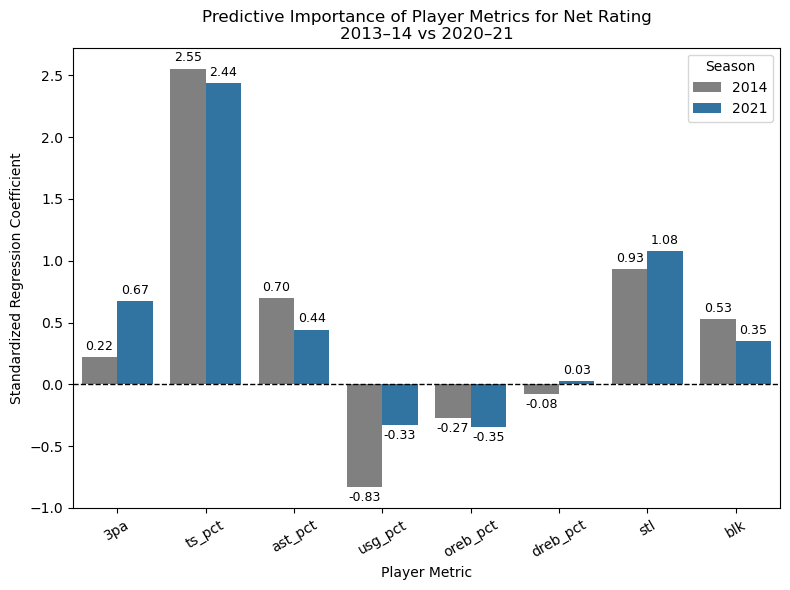

In [8]:
rq1 = adv[adv['year'].isin([2014, 2021])].copy()

metrics = [
    '3pa',
    'ts_pct',
    'ast_pct',
    'usg_pct',
    'oreb_pct',
    'dreb_pct',
    'stl',
    'blk'
]

rows = []

for yr in [2014, 2021]:

    df = rq1[rq1['year'] == yr]

    X = df[metrics]
    y = df['net_rating']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearRegression()
    model.fit(X_scaled, y)

    for metric, coef in zip(metrics, model.coef_):
        rows.append({
            "metric": metric,
            "coefficient": coef,
            "year": yr
        })

coef_df = pd.DataFrame(rows)

plt.figure(figsize=(8,6))

sns.barplot(
    data=coef_df,
    x="metric",
    y="coefficient",
    hue="year",
    palette={2014: "gray", 2021: "#1f77b4"}
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Predictive Importance of Player Metrics for Net Rating\n2013–14 vs 2020–21")
plt.xlabel("Player Metric")
plt.ylabel("Standardized Regression Coefficient")

plt.xticks(rotation=30)

# Add labels on top of bars
for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt='%.2f',   # format to 2 decimal places
        padding=3,
        fontsize=9
    )

plt.legend(title="Season")
plt.tight_layout()
plt.show()

This figure compares how strongly different player metrics predict **player net rating** in the **2013–14 and 2020–21 NBA seasons**, allowing us to examine how the importance of specific skills has evolved over time.

Overall, the chart indicates a clear shift toward **perimeter-oriented offensive play** as a key driver of player impact. Three-point attempt volume (3PA) increases substantially in predictive strength, rising from a relatively small coefficient in 2013–14 to a much larger positive coefficient in 2020–21. This suggests that high-volume three-point shooting has become significantly more associated with positive on-court impact in the modern NBA.

True shooting percentage (TS%) remains the **strongest predictor of net rating in both seasons**, with large positive coefficients in each. However, its influence decreases slightly in 2020–21 compared to 2013–14, indicating that while efficiency is still critical, it may be less differentiating in a league where efficient scoring is more widespread.

Assist percentage (AST%) shows a noticeable decline in predictive power, dropping from a moderate positive coefficient in 2013–14 to a smaller one in 2020–21. This suggests that while playmaking remains valuable, it may be less uniquely tied to player impact as offensive responsibilities become more distributed across lineups.

Usage rate (USG%) remains negatively associated with net rating in both seasons, though it becomes less negative in 2020–21. This implies that high-usage roles are still associated with lower efficiency or tougher shot creation, but modern high-usage players may be better optimized within offensive systems.

Rebounding metrics show mixed trends. Offensive rebounding percentage (OREB%) becomes slightly more negative in 2020–21, while defensive rebounding percentage (DREB%) shifts from slightly negative to near neutral. These patterns suggest that traditional rebounding contributions may play a smaller or more context-dependent role in determining overall player impact in the modern game.

Defensive activity metrics—steals (STL) and blocks (BLK)—remain positively associated with net rating in both seasons. Steals, in particular, increase in predictive strength in 2020–21, while blocks decline slightly, indicating a possible shift toward perimeter-oriented defensive impact rather than interior rim protection.

Taken together, this visualization suggests that **the drivers of player impact have evolved alongside the NBA’s transition toward a faster, spacing-focused, and perimeter-oriented style of play**. While efficiency remains fundamental, skills tied to three-point shooting and modern offensive structure have become more important in explaining player net rating, directly addressing the research question about how the predictive power of key performance metrics has changed between these two eras.

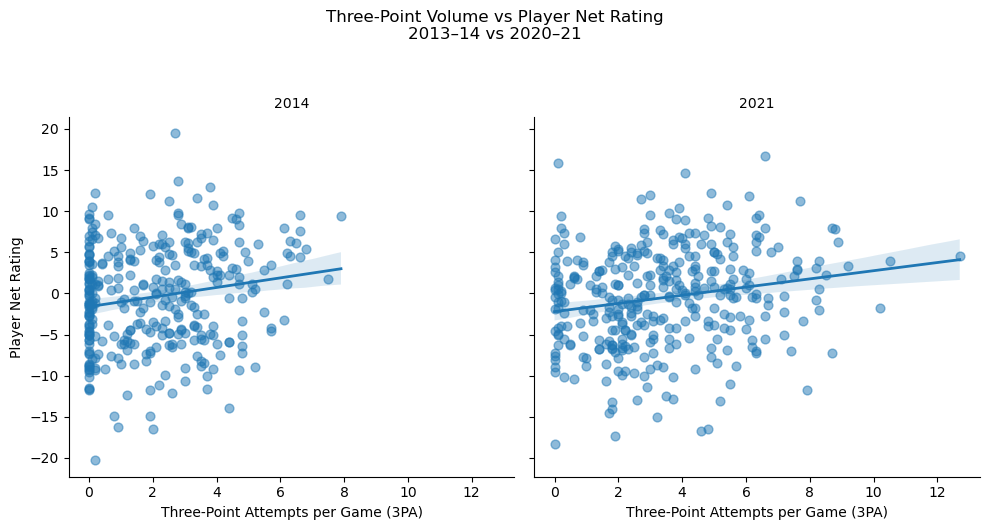

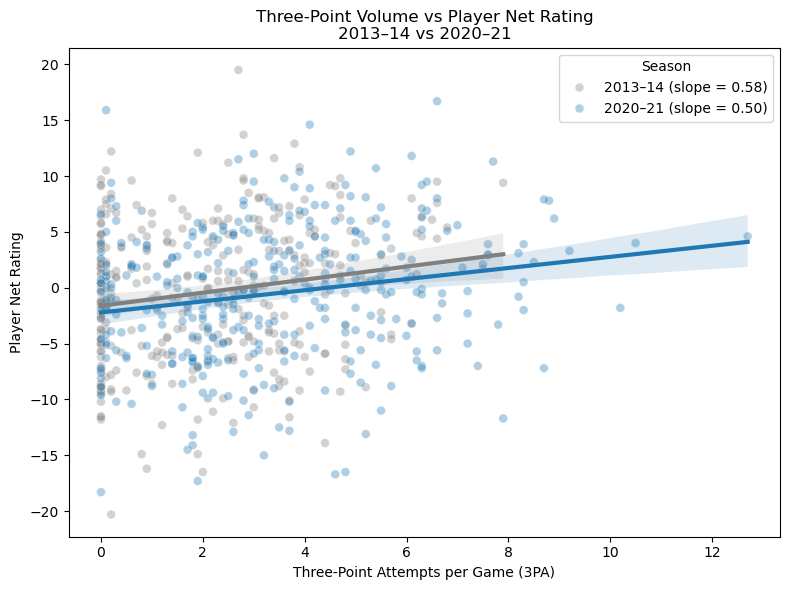

In [9]:
rq1_df = adv[adv["year"].isin([2014, 2021])].copy()

# --- Facet Plot (by year) ---
g = sns.lmplot(
    data=rq1_df,
    x="3pa",
    y="net_rating",
    col="year",
    palette={2014:"gray", 2021:"#1f77b4"},
    scatter_kws={"alpha":0.5, "s":40},
    line_kws={"linewidth":2},
    height=5,
    aspect=1
)

# Set axis labels and titles
g.set_axis_labels("Three-Point Attempts per Game (3PA)", "Player Net Rating")
g.set_titles("{col_name}")  # shows 2014 / 2021

# Add overall title
g.fig.suptitle("Three-Point Volume vs Player Net Rating\n2013–14 vs 2020–21", y=1.05)

plt.tight_layout()
plt.show()

slopes = {}

for yr in [2014, 2021]:
    df = rq1_df[rq1_df["year"] == yr]
    
    X = df[["3pa"]].values
    y = df["net_rating"].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    slopes[yr] = model.coef_[0]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rq1_df,
    x="3pa",
    y="net_rating",
    hue="year",
    palette={2014:"gray", 2021:"#1f77b4"},
    alpha=0.35,
    s=40
)

sns.regplot(
    data=rq1_df[rq1_df["year"] == 2014],
    x="3pa",
    y="net_rating",
    scatter=False,
    color="gray",
    line_kws={"linewidth":3}
)

sns.regplot(
    data=rq1_df[rq1_df["year"] == 2021],
    x="3pa",
    y="net_rating",
    scatter=False,
    color="#1f77b4",
    line_kws={"linewidth":3}
)

plt.title("Three-Point Volume vs Player Net Rating\n2013–14 vs 2020–21")
plt.xlabel("Three-Point Attempts per Game (3PA)")
plt.ylabel("Player Net Rating")

# Clean legend with slopes
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(
    handles,
    [
        f"2013–14 (slope = {slopes[2014]:.2f})",
        f"2020–21 (slope = {slopes[2021]:.2f})"
    ],
    title="Season"
)

plt.tight_layout()
plt.show()

This figure visualizes the relationship between **three-point attempt volume (3PA)** and **player net rating** in the **2013–14 and 2020–21 NBA seasons**, illustrating how the impact of perimeter shooting has evolved over time.

In both seasons, the regression lines slope upward, indicating a **positive relationship between three-point volume and player impact**. Players who attempt more three-pointers per game tend, on average, to have higher net ratings. The strength of this relationship is relatively similar across the two seasons, with slopes of approximately **0.58 in 2013–14 and 0.50 in 2020–21**. This suggests that while three-point volume remains positively associated with player impact, the marginal effect of additional attempts has not dramatically increased over this period.

However, the most notable difference lies in the **distribution of player shot profiles**. In the 2013–14 season, a large concentration of players attempted **0–2 three-pointers per game**, reflecting a more traditional offensive structure where perimeter shooting was less central. In contrast, the 2020–21 distribution shifts significantly to the right, with many players attempting **4–8 or more three-pointers per game**. This highlights a substantial league-wide increase in three-point shooting volume.

Despite the continued variability in net rating—indicating that many factors influence player impact—the broader spread of high-volume shooters in 2020–21 demonstrates that three-point shooting has become a **standard component of offensive roles across positions**, rather than a specialized skill.

Taken together with Figure 1, this visualization suggests that while the **per-attempt impact of three-point shooting has remained relatively stable**, its **prevalence across the league has increased dramatically**. This reinforces the conclusion that the modern NBA is defined not just by the effectiveness of three-point shooting, but by its widespread adoption as a central feature of offensive strategy. Additionally, this is consistent with the league’s broader transition toward pace-and-space offensive strategies.

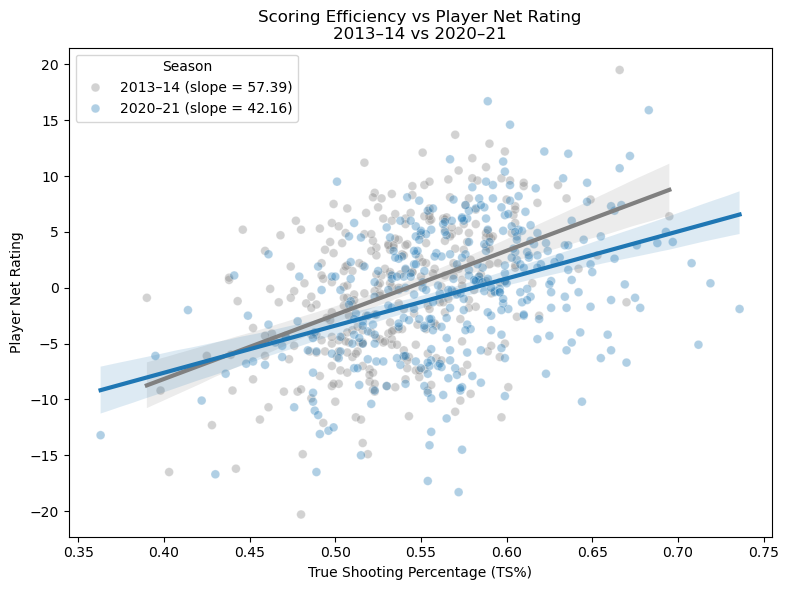

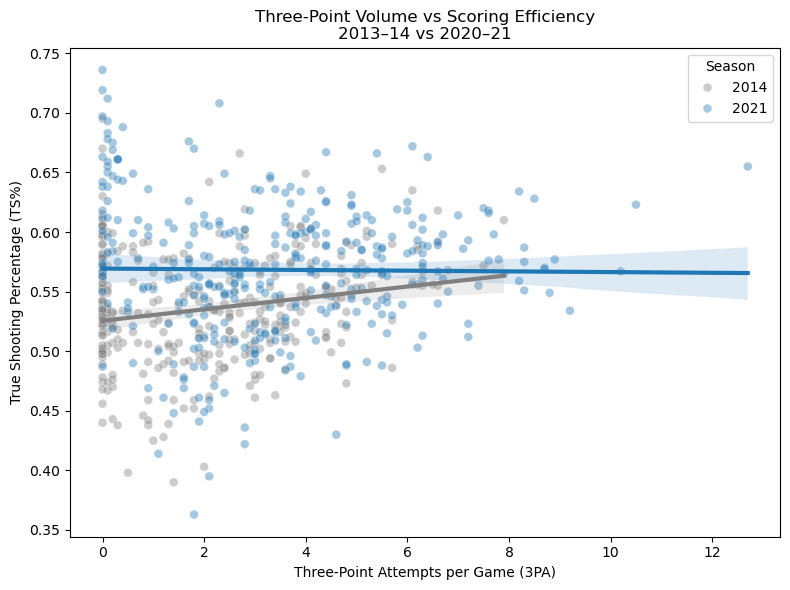

In [10]:
slopes_ts = {}

for yr in [2014, 2021]:
    df = rq1_df[rq1_df["year"] == yr]

    X = df[["ts_pct"]].values
    y = df["net_rating"].values

    model = LinearRegression()
    model.fit(X, y)

    slopes_ts[yr] = model.coef_[0]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rq1_df,
    x="ts_pct",
    y="net_rating",
    hue="year",
    palette={2014:"gray", 2021:"#1f77b4"},
    alpha=0.35,
    s=40
)

sns.regplot(
    data=rq1_df[rq1_df["year"] == 2014],
    x="ts_pct",
    y="net_rating",
    scatter=False,
    color="gray",
    line_kws={"linewidth":3}
)

sns.regplot(
    data=rq1_df[rq1_df["year"] == 2021],
    x="ts_pct",
    y="net_rating",
    scatter=False,
    color="#1f77b4",
    line_kws={"linewidth":3}
)

plt.title("Scoring Efficiency vs Player Net Rating\n2013–14 vs 2020–21")
plt.xlabel("True Shooting Percentage (TS%)")
plt.ylabel("Player Net Rating")

# Clean legend with slopes
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(
    handles,
    [
        f"2013–14 (slope = {slopes_ts[2014]:.2f})",
        f"2020–21 (slope = {slopes_ts[2021]:.2f})"
    ],
    title="Season"
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rq1_df,
    x="3pa",
    y="ts_pct",
    hue="year",
    palette={2014: "gray", 2021: "#1f77b4"},
    alpha=0.4,
    s=40
)

sns.regplot(
    data=rq1_df[rq1_df["year"] == 2014],
    x="3pa",
    y="ts_pct",
    scatter=False,
    color="gray",
    line_kws={"linewidth":3}
)

sns.regplot(
    data=rq1_df[rq1_df["year"] == 2021],
    x="3pa",
    y="ts_pct",
    scatter=False,
    color="#1f77b4",
    line_kws={"linewidth":3}
)

plt.title("Three-Point Volume vs Scoring Efficiency\n2013–14 vs 2020–21")
plt.xlabel("Three-Point Attempts per Game (3PA)")
plt.ylabel("True Shooting Percentage (TS%)")

plt.legend(title="Season")

plt.tight_layout()
plt.show()

This figure examines the relationship between **true shooting percentage (TS%) and player net rating** in the **2013–14 and 2020–21 NBA seasons**, providing a direct comparison of how scoring efficiency translates to on-court impact across eras.

The plot shows a clear **positive relationship between TS% and net rating in both seasons**, confirming that scoring efficiency remains a strong predictor of player impact. Players with higher TS% tend to have higher net ratings, reinforcing the idea that efficient scoring is fundamentally valuable in contributing to team success.

However, the key insight lies in the **change in the strength of this relationship**. The regression line for the 2020–21 season is noticeably flatter than that of 2013–14, indicating that while TS% remains important, its **marginal impact on net rating has decreased over time**. In other words, increases in scoring efficiency are associated with smaller gains in player impact in the modern NBA compared to a decade earlier.

This shift is directly relevant to the research question, as it highlights a change in the **predictive power of scoring efficiency**. When interpreted alongside Figures 1 and 2, a broader pattern emerges. Figure 1 shows that TS% remains the strongest predictor in a multivariate context but has slightly declined in relative importance. Figure 2 shows that while the per-unit relationship between three-point attempts (3PA) and net rating remains similar, the **distribution of 3PA has expanded significantly**, reflecting a league-wide shift toward perimeter shooting.

The accompanying plot of **3PA versus TS%** helps explain this change. In the 2013–14 season, there is a slight positive relationship between three-point volume and efficiency, suggesting that higher-volume shooters were often more selective and efficient. In contrast, the 2020–21 season shows a nearly flat relationship, indicating that **high three-point volume is no longer limited to the most efficient players**. Instead, three-point shooting has become a widespread component of offensive roles across the league.

As a result, scoring efficiency has become more **standardized across players**, reducing its ability to independently distinguish player impact. Efficiency is still essential, but it is increasingly achieved within a **high-volume, perimeter-oriented offensive context**, where factors such as shot profile and spacing play a larger role.

In summary, this visualization demonstrates that **TS% remains a key determinant of player success but is less independently predictive of net rating in the modern NBA**, as its influence is now intertwined with broader structural changes in offensive strategy—particularly the rise of high-volume three-point shooting.


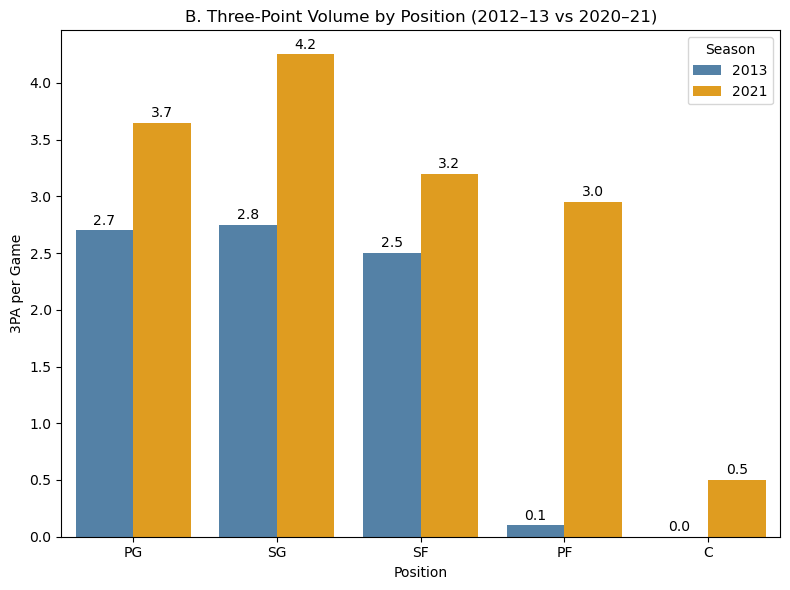

In [11]:
df = adv.copy()

df = adv[
    (adv["year"].isin([2013, 2021])) &
    (adv["g"] >= 20) &
    (adv["mp"] >= 10)
].copy()

metrics = {
    "3pa": "3PA",
    "3p_pct": "3P%",
    "fta": "FTA",
    "trb": "REB",
    "ast": "AST",
    "pts": "PTS"
}

grouped = df.groupby(["year", "pos_simple"])[list(metrics.keys())].median().reset_index()

pivot_2013 = grouped[grouped["year"] == 2013].set_index("pos_simple")
pivot_2021 = grouped[grouped["year"] == 2021].set_index("pos_simple")

common_positions = pivot_2013.index.intersection(pivot_2021.index)

pivot_2013 = grouped[grouped["year"] == 2013].set_index("pos_simple")
pivot_2021 = grouped[grouped["year"] == 2021].set_index("pos_simple")

common_positions = pivot_2013.index.intersection(pivot_2021.index)

pivot_2013 = pivot_2013.loc[common_positions]
pivot_2021 = pivot_2021.loc[common_positions]

order = ["PG", "SG", "SF", "PF", "C"]

three_pa = grouped[["year", "pos_simple", "3pa"]].copy()

plt.figure(figsize=(8,6))

sns.barplot(
    data=three_pa,
    x="pos_simple",
    y="3pa",
    hue="year",
    order=order,
    palette={2013: "steelblue", 2021: "orange"}
)

# Labels
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f", padding=2)

plt.title("B. Three-Point Volume by Position (2012–13 vs 2020–21)")
plt.xlabel("Position")
plt.ylabel("3PA per Game")

plt.legend(title="Season")

plt.tight_layout()
plt.show()